In [31]:
# Demonstration of iTEBD within OQuPy
# Uses the original iTEBD code by Valentin Link from https://github.com/val-link/iTEBD-TEMPO.git.
# Minimally modified by Paul Eastham to take a bath correlation object from OQuPy.
# The resulting object can turned into a new proces tensor subclass, TTInvariantProcessTensor, which should function as all other PTs in OQuPy
# Todo: fully integrate the creation of iTEBD process tensors so we can skip calls to iTEBD_TEMPO_oqupy class.

In [32]:
import oqupy as oqupy
from oqupy.iTEBD_TEMPO_useoqupybath import iTEBD_TEMPO_oqupy
from oqupy.process_tensor import TTInvariantProcessTensor
from oqupy.tti_tempo import TTITempo, TTITempoCounting
import numpy as np
import matplotlib.pyplot as plt

In [38]:
sigma_z = oqupy.operators.sigma("z")
sigma_x = oqupy.operators.sigma("x")
sigma_y = oqupy.operators.sigma("y")
omega_cutoff = 1
alpha = 0.1
temperature = 0.131
correlations = oqupy.PowerLawSD(alpha=alpha,
                                zeta=1,
                                cutoff=omega_cutoff,
                                cutoff_type='exponential',
                                temperature=temperature)
bath = oqupy.Bath(sigma_z/2.0, correlations)

def j(w):
    return 2*alpha*w

u=0.01
correlationscf=oqupy.bath_correlations.CustomCountingSD(j_function=j,cutoff=omega_cutoff,u=u,
                                                 cutoff_type='exponential',temperature=0.131)

bathcf = oqupy.Bath(sigma_z/2.0, correlationscf)



building influence functional: 100%|██████████| 2500/2500 [00:02<00:00, 1245.25it/s]

rank  39
--> Compute dynamics:
  0.0%    0 of  250 [----------------------------------------] 00:00:00

100.0%  250 of  250 [########################################] 00:00:08
Elapsed time: 8.2s


KeyboardInterrupt: 

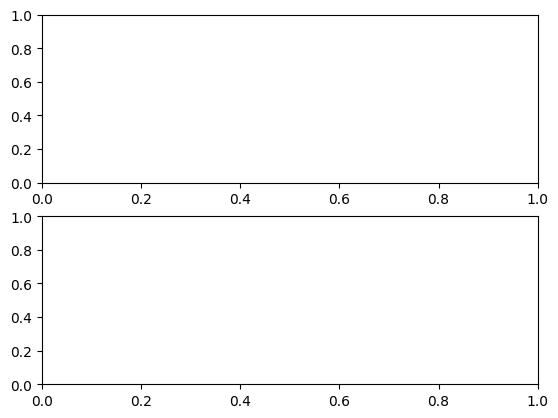

In [40]:
def hamiltonian_t(t):
    return -t*sigma_x/2.0

system = oqupy.TimeDependentSystem(hamiltonian_t)

Rho_0=oqupy.operators.spin_dm('x+')
fig,axs=plt.subplots(2,1)

for dt_var in [0.2,0.1,0.05]:
    parameters=oqupy.TempoParameters(dt=dt_var,epsrel=1e-7,tcut=500)
    pt=TTITempo(bath,start_time=0.0,parameters=parameters)


    dynamics = oqupy.compute_dynamics(
        process_tensor=pt.get_process_tensor(),        
        system=system,
        initial_state=Rho_0,
        start_time=0,
        num_steps=int(50/dt_var))
    
    parameters_cf=oqupy.TempoParameters(dt=dt_var,epsrel=1e-5,tcut=1000)
    pt_cf=TTITempoCounting(bathcf,start_time=0.0,parameters=parameters_cf)
    
    dynamics_cf = oqupy.compute_dynamics(
        process_tensor=pt_cf.get_process_tensor(),        
        system=system,
        initial_state=Rho_0,
        start_time=0,
        num_steps=int(50/dt_var))

    t, s_x = dynamics.expectations(sigma_x, real=True)
    heat = dynamics_cf.states.trace(axis1=1,axis2=2).imag/u

    fig.suptitle(f"iTEBD with dt={dt_var}")
    axs[0].plot(t,s_x,label='dt='+str(dt_var))
    axs[1].plot(t,heat,label='heat dt='+str(dt_var))

    plt.legend()


building influence functional: 100%|██████████| 5000/5000 [00:03<00:00, 1268.52it/s]

rank  145
--> Compute dynamics:
  1.6%    4 of  250 [----------------------------------------] 00:00:00

100.0%  250 of  250 [########################################] 00:00:08
Elapsed time: 8.5s


building influence functional: 100%|██████████| 5000/5000 [00:03<00:00, 1553.35it/s]

rank  79
--> Compute dynamics:
  0.8%    4 of  500 [----------------------------------------] 00:00:00

100.0%  500 of  500 [########################################] 00:00:16
Elapsed time: 16.5s


building influence functional: 100%|██████████| 5000/5000 [00:02<00:00, 1690.57it/s]

rank  40
--> Compute dynamics:
  0.0%    0 of 1000 [----------------------------------------] 00:00:00

100.0% 1000 of 1000 [########################################] 00:00:33
Elapsed time: 33.5s


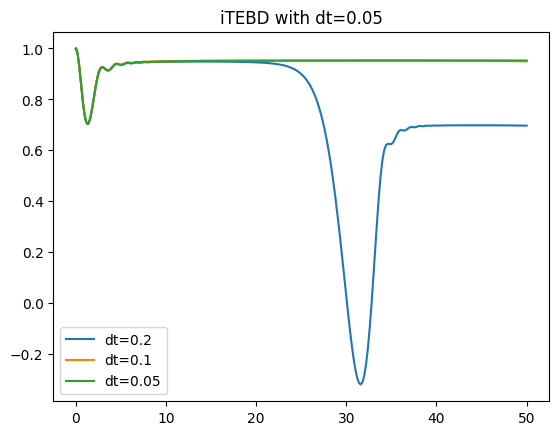

In [17]:
def hamiltonian_t(t):
    return -t*sigma_x/2.0

system = oqupy.TimeDependentSystem(hamiltonian_t)

Rho_0=oqupy.operators.spin_dm('x+')

for dt_var in [0.2,0.1,0.05]:
    parameters=oqupy.TempoParameters(dt=dt_var,epsrel=1e-7,dkmax=5000)
    pt=TTITempo(bath,start_time=0.0,parameters=parameters)

    dynamics = oqupy.compute_dynamics(
        process_tensor=pt.get_process_tensor(),        
        system=system,
        initial_state=Rho_0,
        start_time=0,
        num_steps=int(50/dt_var))

    t, s_x = dynamics.expectations(sigma_x, real=True)

    plt.title(f"iTEBD with dt={dt_var}")
    plt.plot(t,s_x,label='dt='+str(dt_var))
    plt.legend()
